# Simple Grid World: Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define an Empty 5x5 Grid 

A maze without walls. The step cost is 1. The start is (0,0) and
the goal (+100 reward) is (4,4).
This is the ideal problem for a linear approximation of the Q-function
using the x/y location as state features.

In [3]:
from gym_classics.envs.abstract.gridworld import Gridworld

class EmptyGridworld(Gridworld):
    layout = """
|    G|
|     |
|     |
|     |
|S    |
"""

    def __init__(self):
        super().__init__(self.layout)

    def _reward(self, state, action, next_state):
        if state in self._goals:
            return 0.0
        return {(4, 4): 100.0}.get(next_state, -1)

    def _done(self, state, action, next_state):
        return next_state in self._goals   

gym.register('EmptyGridworld-v1', entry_point=EmptyGridworld)

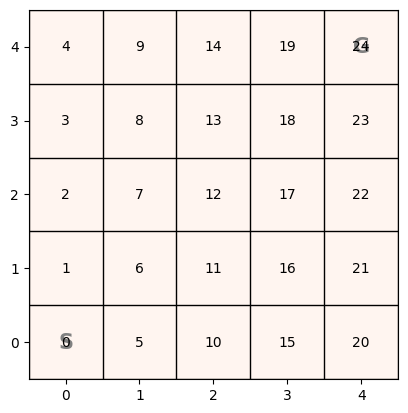

In [4]:
gym_env = gym.make('EmptyGridworld-v1')
env = gym_env.unwrapped

env.image()

In [6]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

sample_episode(env, max_len=10000)

[(0, 1, -1, 5),
 (5, 0, -1, 6),
 (6, 0, -1, 7),
 (7, 3, -1, 2),
 (2, 3, -1, 2),
 (2, 2, -1, 1),
 (1, 0, -1, 2),
 (2, 3, -1, 2),
 (2, 2, -1, 1),
 (1, 3, -1, 1),
 (1, 3, -1, 1),
 (1, 1, -1, 6),
 (6, 1, -1, 11),
 (11, 3, -1, 6),
 (6, 2, -1, 5),
 (5, 3, -1, 0),
 (0, 1, -1, 5),
 (5, 0, -1, 6),
 (6, 0, -1, 7),
 (7, 2, -1, 6),
 (6, 1, -1, 11),
 (11, 2, -1, 10),
 (10, 3, -1, 5),
 (5, 2, -1, 5),
 (5, 1, -1, 10),
 (10, 3, -1, 5),
 (5, 2, -1, 5),
 (5, 3, -1, 0),
 (0, 3, -1, 0),
 (0, 2, -1, 0),
 (0, 2, -1, 0),
 (0, 3, -1, 0),
 (0, 2, -1, 0),
 (0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 2, -1, 0),
 (0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 3, -1, 0),
 (0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 3, -1, 0),
 (0, 1, -1, 5),
 (5, 0, -1, 6),
 (6, 2, -1, 5),
 (5, 3, -1, 0),
 (0, 0, -1, 1),
 (1, 3, -1, 1),
 (1, 2, -1, 0),
 (0, 0, -1, 1),
 (1, 2, -1, 0),
 (0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 1, -1, 5),
 (5, 0, -1, 6),
 (6, 3, -1, 1),
 (1, 3, -1, 1),
 (1, 2, -1, 0),
 (0, 2, -1, 0),
 (0, 1, -1, 5),
 (5, 3, -1, 0),
 (0, 2, -1, 0),


## State Features

We use here simply the x and y-coordinates as the state feature vector $\mathbf{x}(s)$. We also add an intercept (a 1) to the beginning so we end up with a 3-dimensional state feature.

`[intercept (always 1), x, y]`


In [8]:
def state_features(s):
    coord = env.decode(s)
    return np.concatenate([np.array([1]), np.array(coord)])

In [9]:
display(state_features(0))
display(state_features(1))

array([1, 0, 0])

array([1, 0, 1])

Linear approximation of the value function just mean we calculate a weighted sum of the state feature components:

$\hat{v}(s,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$, 

where $\mathbf{w}$ is the weight vector we want to learn.

In [10]:
def v_hat(s, w):
    x_s = state_features(s)
    return np.dot(w, x_s)

For example, I manually define here a weight vector.

In [11]:
w = np.array([1, 5, 10])

This means the smallest value at $(0,0)$ is the intercept of 1 and the value function increases by 5 for every step in the x direction and ny
10 in the y direction.

In [12]:

print (f" v_hat((0,0), w) = {v_hat(env.encode((0,0)), w)}")
print (f" v_hat((4,4), w) = {v_hat(env.encode((4,4)), w)}")

 v_hat((0,0), w) = 1
 v_hat((4,4), w) = 61


Here is the value function for the weights.

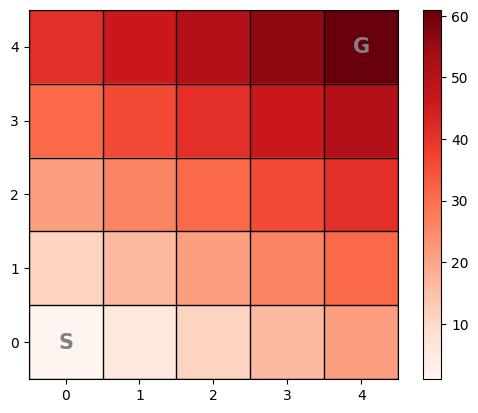

In [13]:
V = np.array([v_hat(s, w) for s in range(env.observation_space.n)])
env.image(V)

We can visualize the learned value function using contours.

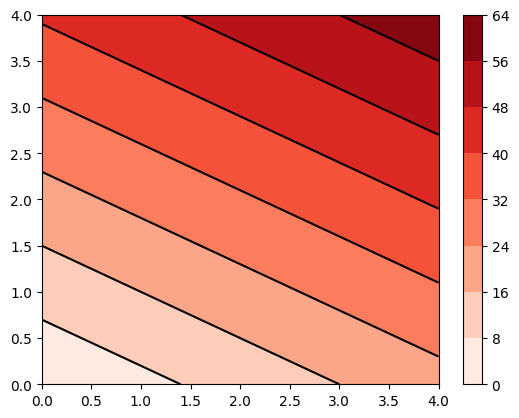

In [14]:
from matplotlib import pyplot as plt

def v_hat_grid(x, y, w):
    return np.dot(w, [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

Z = np.array([v_hat_grid(x, y, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

plt.contourf(X, Y, Z, cmap='Reds')
plt.colorbar()
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()

# Learning w for a given Policy 


We want to minimize the mean square value error: $\overline{VE} = \sum_{s\in \mathcal{S}} \mu(s) [v_\pi - \hat{v}(s, \mathbf{w})]^2$

This leads to:

* SGD update: $\mathbf{w}_{t+1} = \mathbf{w}_t + \alpha (U_t - \hat{v}(S_t, \mathbf{w}_t)) \mathbf{x}(S_t)$
* Gradient: $\nabla \hat{v}(s, \mathbf{w}) = \mathbf{x}(s)$


We could use the gradient Monte Carlo algorithm, but we show here the
Semi-Gradient TD(0) Algorithm with Linear Function Approximation.



![Semi-Gradient TD(0)](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_TD0.png)

In [15]:
def semi_gradient_TD0_estimation(env, policy, n, alpha, gamma, max_episode_length=100, verbose = True):
    assert isinstance(env, gym.Env), "env must be an instance of gym.Env"
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"
    
    w = np.zeros(state_features(0).shape[0])  # Initialize weights (intercept + x and y)

    for episode in range(n):
        state, _ = env.reset()
        done = False

        i = 0
        while not done and i < max_episode_length:
            action = policy[state]  # follow policy
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Semi-gradient TD(0) update
            # Note: v_hat(terminal, w) needs to be 0
            if terminated:
                w += alpha * (reward - v_hat(state, w)) * state_features(state)    
            else: 
                w += alpha * (reward + gamma * v_hat(next_state, w) - v_hat(state, w)) * state_features(state)
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            i += 1

    return w

I will manually create a policy to evaluate.

In [16]:
pol = np.full(env.observation_space.n, env.encode_action('up'))
pol[[4, 9, 14, 19]] = env.encode_action('right')
pol

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0])

In [17]:
w = semi_gradient_TD0_estimation(env, pol, n=1000, alpha=0.01, gamma=1, verbose=False)
w

array([93.,  1.,  1.])

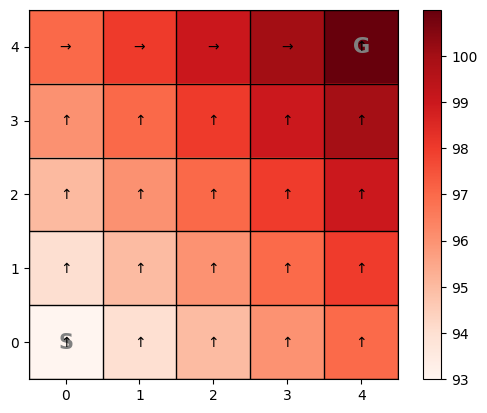

In [18]:
V = np.array([v_hat(s, w) for s in range(env.observation_space.n)])
env.image(V, policy=pol)

In [19]:
V.reshape(5,5)[::-1]

array([[ 97.,  98.,  99., 100., 101.],
       [ 96.,  97.,  98.,  99., 100.],
       [ 95.,  96.,  97.,  98.,  99.],
       [ 94.,  95.,  96.,  97.,  98.],
       [ 93.,  94.,  95.,  96.,  97.]])

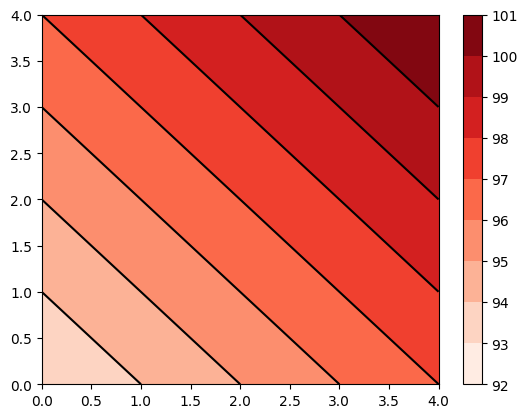

In [20]:
from matplotlib import pyplot as plt

def v_hat_grid(x, y, w):
    return np.dot(w, [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

Z = np.array([v_hat_grid(x, y, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

plt.contourf(X, Y, Z, cmap='Reds')
plt.colorbar()
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()

# Semi-Gradient Sarsa

![Semi-Gradient Sarsa](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Semi_gradient_SARSA.png)

To construct a linear state-action approximation function is a little more tricky. [Geramifard et al. (2013)](https://doi.org/10.1561/2200000042) suggest to use a state feature vectors to construct the complete state-action feature vector. It uses one shared intercept and then for each action a state feature component.
In our case we get a $w$ vectors of length 1 intercept + 4 actions $\times$ 2 coordinate values = 9. Here is the layout for the weight vector $\mathbf{w}$:

`[intercept, x_action0, y_action0, x_action1, y_action1, x_action2, y_action2, x_action3, y_action3]`

Only the intercept and the weights belonging to the action are used.

In [21]:
# choose intercept at 0 and the action-specific weights so we end up with 3 active weights.
def active_weights(a):
    return [0, a * 2 + 1, a * 2 + 2]

active_weights(1)

[0, 3, 4]

In [22]:
def q_hat(s, a, w): 
    return np.dot(w[active_weights(a)], state_features(s))

In [23]:
w = np.array([1,2,2,3,3,4,4,5,5])

# state 7 is (2,1): for action 2 this should be 1 (intercept) + 2*4+1*4 = 13
q_hat(7, 2, w)

np.int64(13)

In [24]:
def semi_gradient_Sarsa(env, n, epsilon, alpha, gamma, w = None, max_episode_length=100, verbose = True):
    assert isinstance(env, gym.Env), "env must be an instance of gym.Env"
    assert alpha > 0 and alpha <= 1, "Alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "Gamma must be in [0,1]"
    assert epsilon >=0 and epsilon <=1, "Epsilon must be in [0,1]"
    assert n > 0, "Number of episodes must be positive"
    assert max_episode_length > 0, "Max episode length must be positive"

    if w is None:
        w = np.zeros(9)  # Initialize weights (intercept + action weights)

    # helper used later
    def epsilon_greedy_action(state, epsilon):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        else:
            q_values = [q_hat(state, a, w) for a in range(env.action_space.n)]
            return np.argmax(q_values)
    
    for episode in range(n):
        state, _ = env.reset()
        action = epsilon_greedy_action(state, epsilon)
        done = False

        i = 0
        while not done and i < max_episode_length:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            if terminated:
                next_action = None
                w[active_weights(action)] += alpha * (reward - q_hat(state, action, w)) * state_features(state)
                
            else:
                next_action = epsilon_greedy_action(next_state, epsilon)
                w[active_weights(action)] += alpha * (reward + gamma * q_hat(next_state, next_action, w) - q_hat(state, action, w)) * state_features(state)
             
            if verbose:
                print (f"Episode {episode+1}, Step {i+1}: S={state}, A={action}, R={reward}, S'={next_state}, w={w}")

            state = next_state
            action = next_action
            i += 1

    return w  
    

### Tests With Different Learning Rates 

In [25]:
from gym_classics.algorithms.policy import greedy_policy

# helper to visualize the learned policy and value function 
def plot_w(w, title=None):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    pol = greedy_policy(env, V)
    env.image(V, policy=pol, title=title)
    
    return Q, V, pol

Convergence is an issue with semi-gradient methods and depends on the choice of the learning rate.

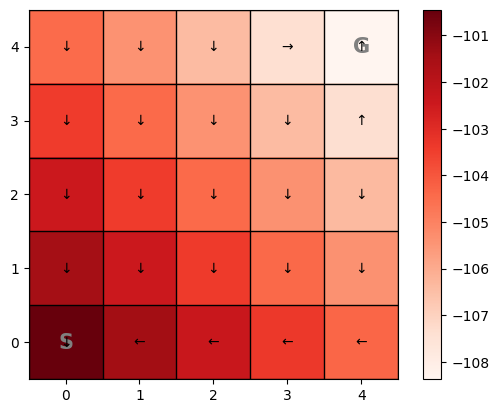

(array([[-100.45, -100.45, -100.45, -100.45],
        [-102.84, -102.64, -101.45, -102.11],
        [-105.24, -104.84, -102.45, -103.77],
        [-107.63, -107.03, -103.45, -105.44],
        [-110.02, -109.23, -104.45, -107.1 ],
        [-101.46, -101.52, -101.43, -101.42],
        [-103.86, -103.72, -102.43, -103.08],
        [-106.25, -105.92, -103.43, -104.74],
        [-108.65, -108.11, -104.43, -106.41],
        [-111.04, -110.31, -105.43, -108.07],
        [-102.48, -102.6 , -102.41, -102.38],
        [-104.88, -104.8 , -103.41, -104.05],
        [-107.27, -106.99, -104.41, -105.71],
        [-109.67, -109.19, -105.41, -107.38],
        [-112.06, -111.39, -106.41, -109.04],
        [-103.5 , -103.68, -103.39, -103.35],
        [-105.9 , -105.88, -104.39, -105.02],
        [-108.29, -108.07, -105.39, -106.68],
        [-110.68, -110.27, -106.39, -108.34],
        [-113.08, -112.47, -107.39, -110.01],
        [-104.52, -104.76, -104.38, -104.32],
        [-106.91, -106.96, -105.38

In [26]:
w = semi_gradient_Sarsa(env, n=100, epsilon=0.1, alpha=0.01, gamma=1, verbose=False)
plot_w(w)

Learning most likely did not converge! We need to reduce the learning rate.

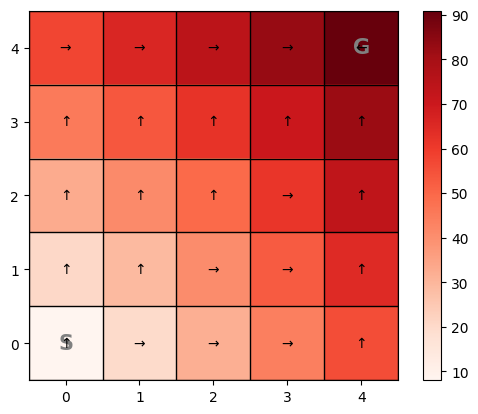

In [30]:
w = semi_gradient_Sarsa(env, n=100, epsilon=0.1, alpha=0.001, gamma=1, verbose=False)
Q, V, pol = plot_w(w)

The policy looks much better. The policy points towards the shortest path to the goal. 

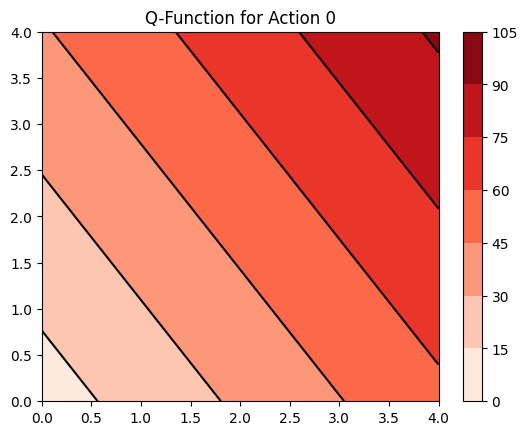

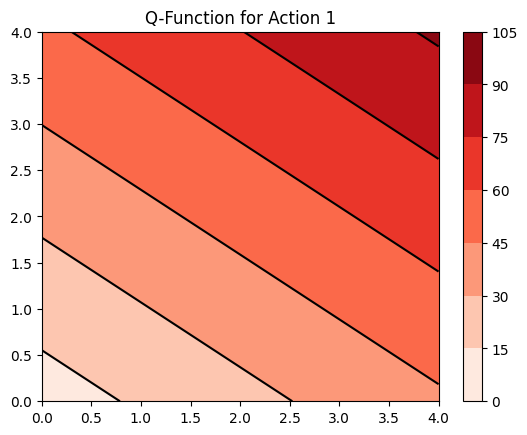

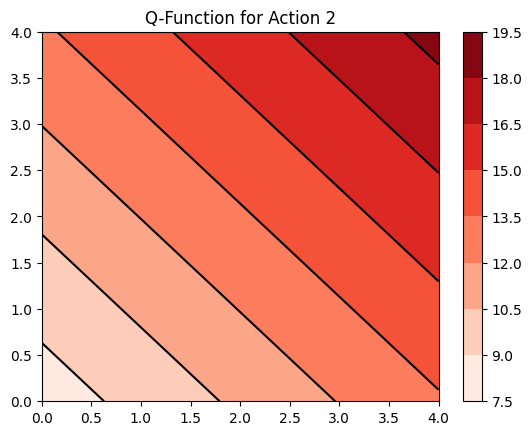

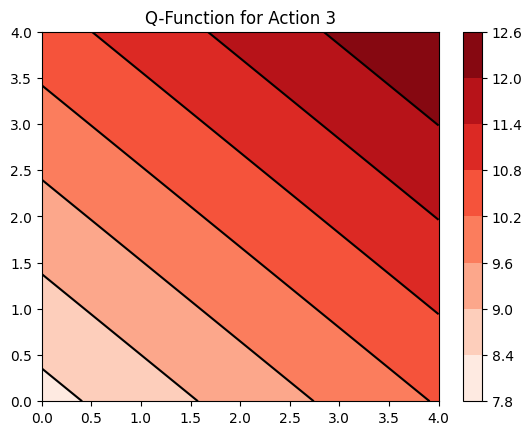

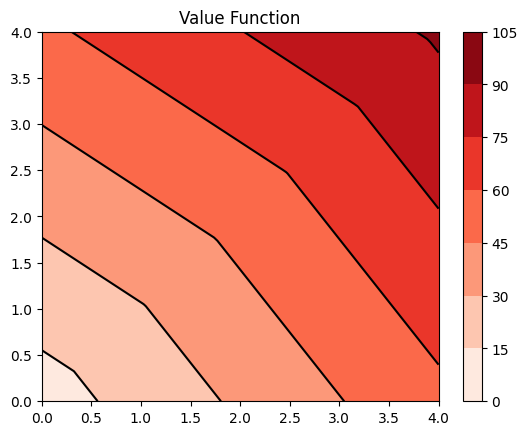

In [28]:
from matplotlib import pyplot as plt

def q_hat_grid(x, y, a, w):
    return np.dot(w[active_weights(a)], [1, x, y])

x = np.linspace(0, 4, 100)
y = np.linspace(0, 4, 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(env.action_space.n):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

    plt.contourf(X, Y, Z, cmap='Reds')
    plt.colorbar()
    plt.title(f'Q-Function for Action {a}')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='Reds')
plt.colorbar()
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()


Let's compare the learned value function with it with the optimal value function. Since we have model access, we can calculate it using value iteration.

In [32]:
from gym_classics.algorithms.dynamic_programming import value_iteration
V_true = value_iteration(env, discount = 1)
V_true 

array([ 93.,  94.,  95.,  96.,  97.,  94.,  95.,  96.,  97.,  98.,  95.,
        96.,  97.,  98.,  99.,  96.,  97.,  98.,  99., 100.,  97.,  98.,
        99., 100., 100.])

In [33]:
# mean squared value error
def MSVE(V, V_true):
    return np.sqrt(np.mean((V - V_true)**2))

In [34]:
msve = MSVE(V, V_true)
msve_sqrt = np.sqrt(msve)

print(f"MSVE: {msve}, sqrt(MSVE): {msve_sqrt}")

MSVE: 48.467303763285216, sqrt(MSVE): 6.961846289834702


### Experiment With Learning

In [35]:
w = np.zeros(9)
w_list = []

for _ in range(1000):
    w = semi_gradient_Sarsa(env, n=1, epsilon=0.1, alpha=0.001, gamma=1, w = w, verbose=False)
    w_list.append(w.copy())

display(w_list)

[array([ 0.02,  0.37,  0.25, -0.03, -0.05, -0.03, -0.05, -0.03, -0.04]),
 array([-0.07,  0.34, -0.11, -0.03, -0.06, -0.03, -0.06, -0.03, -0.05]),
 array([-0.03,  0.24, -0.27,  0.27,  0.34, -0.03, -0.07, -0.03, -0.06]),
 array([-0.13,  0.22, -0.28, -0.07,  0.2 , -0.04, -0.07, -0.03, -0.06]),
 array([-0.05,  0.61,  0.02, -0.12,  0.15, -0.04, -0.07, -0.03, -0.06]),
 array([-0.03,  0.43, -0.28,  0.17,  0.54, -0.04, -0.07, -0.04, -0.06]),
 array([ 0.01,  0.82,  0.01, -0.04,  0.41, -0.03, -0.07, -0.03, -0.06]),
 array([ 0.06,  0.69, -0.16,  0.25,  0.8 , -0.04, -0.07, -0.03, -0.06]),
 array([ 0.12,  1.08,  0.13,  0.12,  0.7 , -0.03, -0.06, -0.01, -0.05]),
 array([ 0.19,  1.  ,  0.03,  0.41,  1.09, -0.03, -0.06, -0.01, -0.05]),
 array([ 0.26,  1.38,  0.31,  0.27,  0.98, -0.03, -0.06,  0.01, -0.03]),
 array([ 0.33,  1.32,  0.23,  0.56,  1.36, -0.02, -0.05,  0.01, -0.03]),
 array([ 0.41,  1.32,  0.23,  0.77,  1.68, -0.02, -0.05,  0.03, -0.02]),
 array([ 0.43,  1.7 ,  0.51,  0.4 ,  1.44,  0.02, -

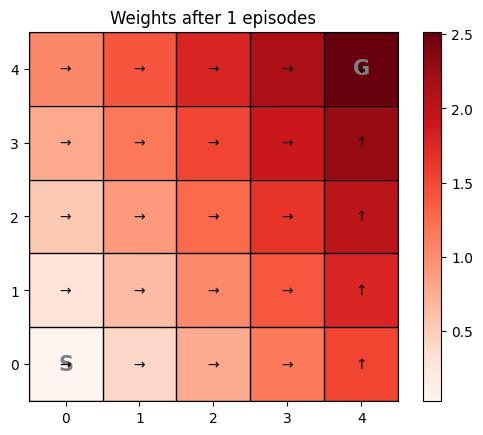

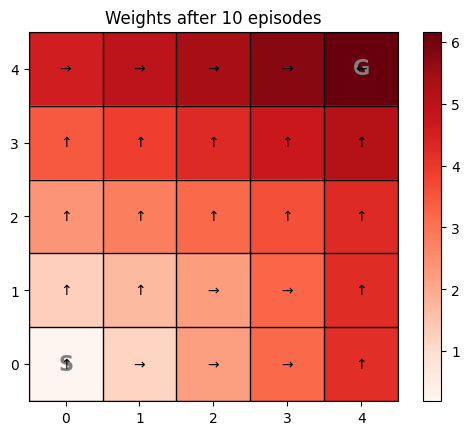

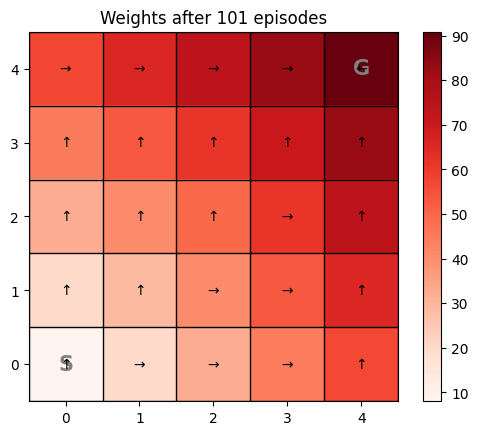

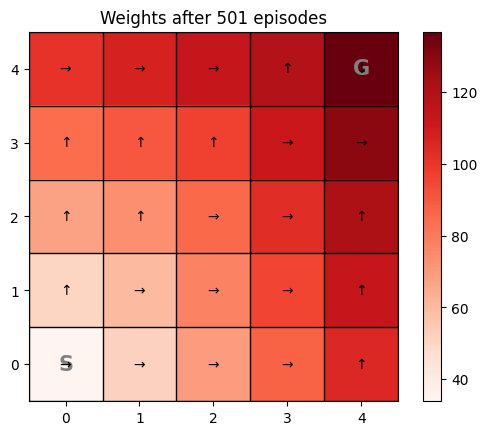

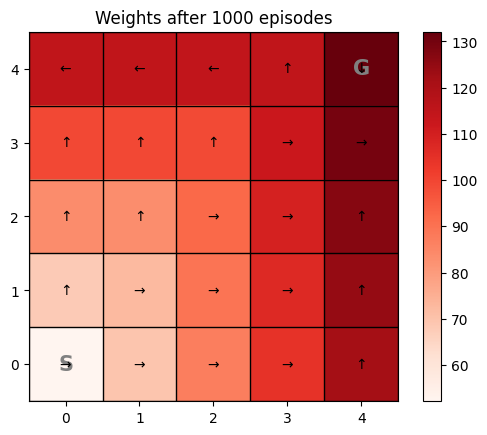

In [36]:
for i in [0,9, 100, 500, 999]:
    Q, V, pol = plot_w(w_list[i], title=f"Weights after {i+1} episodes")    

Look at MSVE over episodes.

In [37]:
def MSVE_w(w):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    return MSVE(V, V_true)  

msve = [MSVE_w(w) for w in w_list]

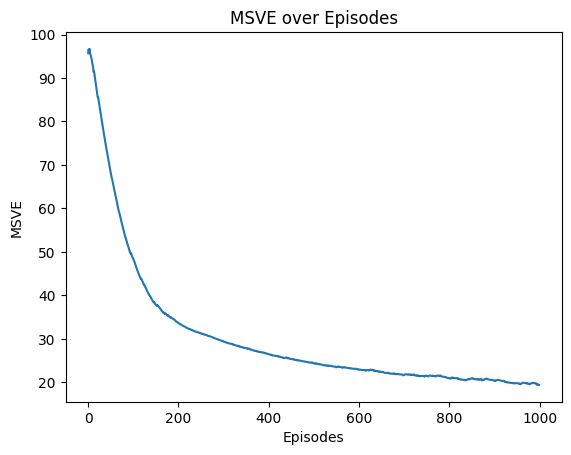

In [38]:
import matplotlib.pyplot as plt 

# plot MSVE over episodes
plt.plot(msve)
plt.xlabel('Episodes')
plt.ylabel('MSVE')
plt.title('MSVE over Episodes')
plt.show()


# Change Learning Rate Over Time

For gradient descent methods,
it is a good idea to reduce the learning rate over time.

In [39]:
w = np.zeros(9)
w_list = []

def alpha_schedule(episode, alpha_0=0.001, k=0.01):
    return alpha_0 / (1 + k * episode)

for i in range(10000):
    w = semi_gradient_Sarsa(env, n=1, epsilon=0.1, alpha=alpha_schedule(i), gamma=1, w = w, verbose=False)
    w_list.append(w.copy())

display(w_list)

[array([ 0.03, -0.05, -0.03,  0.26,  0.37, -0.04, -0.03, -0.04, -0.03]),
 array([-0.07, -0.05, -0.03, -0.08,  0.33, -0.05, -0.03, -0.05, -0.03]),
 array([-0.03,  0.33,  0.26, -0.26,  0.22, -0.06, -0.03, -0.06, -0.03]),
 array([ 0.01,  0.29,  0.05,  0.03,  0.59, -0.06, -0.04, -0.06, -0.03]),
 array([ 0.1 ,  0.66,  0.34,  0.01,  0.58, -0.06, -0.04, -0.06, -0.03]),
 array([ 0.15,  0.55,  0.16,  0.29,  0.94, -0.06, -0.04, -0.05, -0.02]),
 array([ 0.21,  0.92,  0.44,  0.19,  0.87, -0.06, -0.04, -0.04, -0.01]),
 array([ 0.29,  0.9 ,  0.41,  0.46,  1.23, -0.06, -0.04, -0.04, -0.01]),
 array([ 0.36,  1.25,  0.68,  0.34,  1.14, -0.06, -0.04, -0.03, -0.  ]),
 array([ 0.43,  1.22,  0.64,  0.6 ,  1.49, -0.06, -0.04, -0.03, -0.  ]),
 array([ 0.51,  1.54,  0.88,  0.57,  1.46, -0.06, -0.03,  0.  ,  0.03]),
 array([ 0.57,  1.46,  0.78,  0.81,  1.79, -0.06, -0.03,  0.  ,  0.03]),
 array([ 0.63,  1.79,  1.02,  0.74,  1.73, -0.06, -0.03,  0.  ,  0.03]),
 array([ 0.71,  1.75,  0.97,  0.98,  2.05, -0.04, -

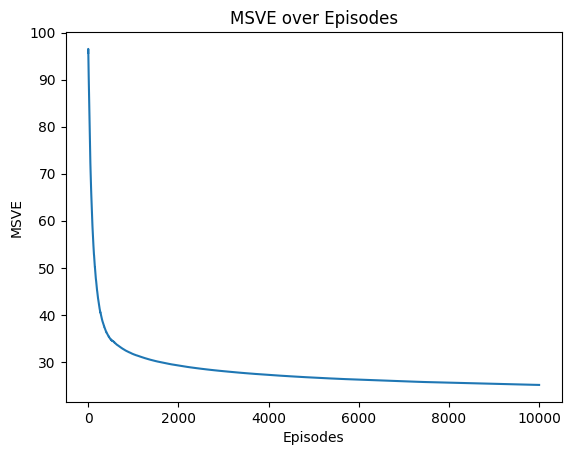

In [40]:
msve = [MSVE_w(w) for w in w_list]

plt.plot(msve)
plt.xlabel('Episodes')
plt.ylabel('MSVE')
plt.title('MSVE over Episodes')
plt.show()

Note: Play with `alpha_0` and `k` to see how instable learning is! 


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)